In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../"))
from utils.gref_pipeline.georef import *

sys.path.append(os.path.abspath("../../"))
from gref_pipeline import config

In [2]:
transect = load_transect(config.OUTPUT_FOLDER)
transect.list_files()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True


In [3]:
cube = transect.select_files(
    [
        # "rad_uhi_20241029_115057_4",
        "rad_uhi_20241029_115057_5",
    ]
)
cube.describe()

🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Loaded full cube: (2462, 968, 210) (T × S × B)

=== Combined_output ===
Tracks × Slits: 2462 × 968
RGB coverage: R/G/B finite ratios 1.00/1.00/1.00

📋 File boundaries:
  rad_uhi_20241029_115057_5: tracks 0–2461 (2462)
✅ Loaded full cube: (2462, 968, 210) (T × S × B)

=== Combined_output ===
Tracks × Slits: 2462 × 968
RGB coverage: R/G/B finite ratios 1.00/1.00/1.00

📋 File boundaries:
  rad_uhi_20241029_115057_5: tracks 0–2461 (2462)


In [4]:
cube.list_saved_corrections()


📋 Cached illumination corrections:

📁 File: rad_uhi_20241029_115057_5
   ✓ window=1000, strength=1.0
     Dataset: dataCube_illum_corrected_w1000_s1p00
     Shape: (2462, 968, 210), Size: 1909.2 MB
   ✓ window=500, strength=1.0
     Dataset: dataCube_illum_corrected_w500_s1p00
     Shape: (2462, 968, 210), Size: 1909.2 MB


In [5]:
# Apply illumination correction with rolling window (window_size=1000 tracks)
# NOTE: Using V2 version (pandas rolling median, no scipy bugs)
# This will be cached to disk - next time it will load instantly!
# Use force_recompute=True to force recalculation
cube.apply_illumination_correction_v2(window_size=750, force_recompute=False)

🔄 Using V2 algorithm (pandas rolling median)
🔄 Computing illumination correction: rolling (window=750), strength=1.0


   Processing slits: 100%|██████████| 968/968 [07:16<00:00,  2.22slit/s]



✅ data_corrected ready (rolling (window=750)) using V2 algorithm
💾 Saving illumination correction to HDF5 files...
💾 Saving illumination correction to 1 files...
   Dataset: processed/radiance/dataCube_illum_corrected_w750_s1p00
   ✓ rad_uhi_20241029_115057_5: saved (2462, 968, 210)
   ✓ rad_uhi_20241029_115057_5: saved (2462, 968, 210)
✅ Illumination correction saved to disk
✅ Illumination correction saved to disk


array([[[3.3569016e+00, 1.5065858e+00, 0.0000000e+00, ...,
         0.0000000e+00, 5.2968793e+00, 0.0000000e+00],
        [8.5391197e+00, 7.5399721e-01, 0.0000000e+00, ...,
         0.0000000e+00, 3.3462751e+00, 0.0000000e+00],
        [2.0152278e+00, 2.1721616e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.8464627e+00, 0.0000000e+00],
        ...,
        [1.7213115e+00, 1.2209128e+00, 0.0000000e+00, ...,
         8.7834549e-01, 2.3279436e-02, 4.6879146e-01],
        [6.7750878e+00, 1.8088993e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.7072159e+00, 0.0000000e+00],
        [2.3867478e+00, 1.0517330e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.1649333e+01, 5.5207127e-01]],

       [[3.3569016e+00, 6.9604844e-01, 4.5374265e+00, ...,
         0.0000000e+00, 0.0000000e+00, 9.6023534e-05],
        [1.9957327e+00, 0.0000000e+00, 1.2654871e+00, ...,
         0.0000000e+00, 9.1909397e-01, 1.0000000e+00],
        [2.1167505e+00, 0.0000000e+00, 3.9580207e+00, ...,
         0.000

In [6]:
cube.adjust_uhi_alignment(dx=-0.05, dy=-3.0)

✅ UHI alignment adjusted:
   dx (East):  -0.050 m
   dy (North): -3.000 m

💡 This will be applied in plot_georef() with coordinate_system='NED'


In [7]:
# Import ROIs from file
cube.import_rois("my_rois.json")

📂 Imported 11 ROIs from my_rois.json


In [8]:
# List all ROIs
cube.list_rois()


📂 ROI Collection (11 ROIs):
 1. 'sed1': 273 pixels
     Slit range:   14 - 870
     Track range: 577 - 1580
 2. 'dark1': 98 pixels
     Slit range:  606 - 740
     Track range: 729 - 765
 3. 'dark2': 140 pixels
     Slit range:  174 - 356
     Track range: 1094 - 1148
 4. 'dark_collected': 68 pixels
     Slit range:  177 - 736
     Track range: 733 - 1149
 5. 'vertical': 62 pixels
     Slit range:  224 - 404
     Track range: 1124 - 1168
 6. 'vertical_inside': 82 pixels
     Slit range:  244 - 291
     Track range: 1126 - 1135
 7. 'tripple': 71 pixels
     Slit range:  662 - 701
     Track range: 593 - 598
 8. 'tripple2': 42 pixels
     Slit range:  639 - 654
     Track range: 700 - 705
 9. 'tripple3': 84 pixels
     Slit range:  632 - 678
     Track range: 757 - 765
10. 'double1': 114 pixels
     Slit range:  809 - 880
     Track range: 1500 - 1516
11. 'double2': 61 pixels
     Slit range:  659 - 690
     Track range: 1540 - 1547


In [9]:
# Example: Combine multiple ROIs
# cube.combine_rois(roi_names_to_combine=["sed1", "sed2"], new_roi_name="all_sediment")

In [10]:
# cube.rename_roi(old_roi_name="sed1", new_roi_name="Sediment")

💡 Interactive mode: Click on the plot to display coordinates


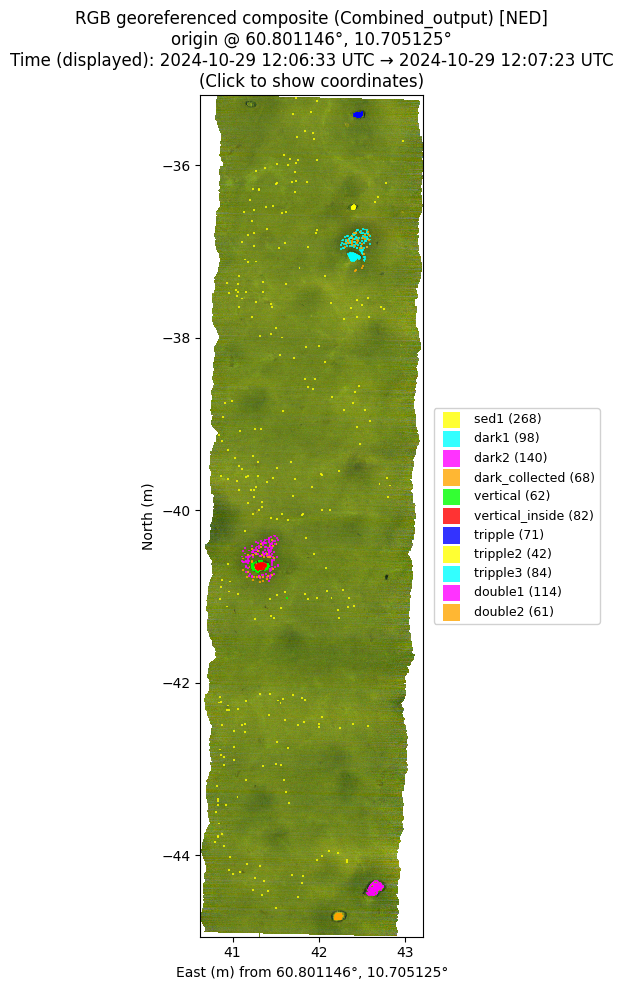

In [11]:
cube.plot_georef(
    apply_alignment_shift=True,
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE_5[0],
    track_end=config.UHI_TRACK_RANGE_5[1],
    figsize=(30, 10),
    roi_collection="all",
    roi_marker_size=2,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)

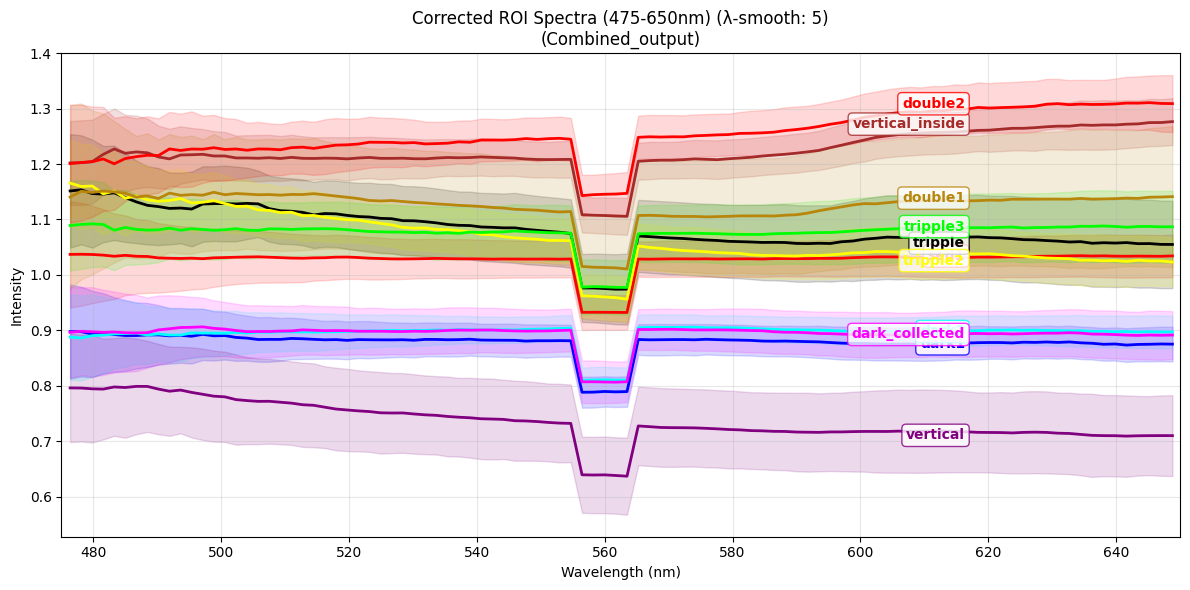

In [12]:
# All ROI spectra with std bands
cube.plot_spectrum(
    roi_names="all",
    use_corrected=True,
    wavelength_range=(475, 650),
    wavelength_smoothing=5,
)

In [13]:
# 🔍 DIAGNOSTIC: Check if window_size=750 has the 560nm dip bug
import numpy as np

# Check which correction is loaded
print(f"📊 Checking data_corrected shape: {cube.data_corrected.shape}")

# Check wavelength 104 (~560nm) in the corrected data
wl_idx = 104
test_roi_name = list(cube.roi_collection.keys())[0]
test_roi = cube.roi_collection[test_roi_name]

spectra_103_w750 = []
spectra_104_w750 = []
spectra_105_w750 = []

for slit, track in list(test_roi)[:30]:  # Check 30 pixels
    track_offset = getattr(cube, "track_offset", 0)
    rel_track = track - track_offset
    if 0 <= rel_track < cube.data_corrected.shape[0]:
        spectra_103_w750.append(cube.data_corrected[rel_track, slit, 103])
        spectra_104_w750.append(cube.data_corrected[rel_track, slit, 104])
        spectra_105_w750.append(cube.data_corrected[rel_track, slit, 105])

print(f"\n🔍 Checking window_size=750 correction for ROI '{test_roi_name}':")
print(
    f"Wavelength 103: Mean={np.mean(spectra_103_w750):.4f}, Std={np.std(spectra_103_w750):.4f}"
)
print(
    f"Wavelength 104: Mean={np.mean(spectra_104_w750):.4f}, Std={np.std(spectra_104_w750):.4f}  ⚠️  CHECK THIS"
)
print(
    f"Wavelength 105: Mean={np.mean(spectra_105_w750):.4f}, Std={np.std(spectra_105_w750):.4f}"
)

# Calculate the dip severity
mean_neighbors = (np.mean(spectra_103_w750) + np.mean(spectra_105_w750)) / 2
mean_104 = np.mean(spectra_104_w750)
dip_percent = ((mean_neighbors - mean_104) / mean_neighbors) * 100

print(f"\n📉 Dip analysis:")
print(f"   Neighbors average: {mean_neighbors:.4f}")
print(f"   Wavelength 104: {mean_104:.4f}")
print(f"   Dip severity: {dip_percent:.1f}%")

if abs(dip_percent) > 10:
    print(
        f"\n❌ CORRUPTION DETECTED! window_size=750 has corrupted data at wavelength 104"
    )
    print(f"   The dip is {dip_percent:.1f}% - this is NOT normal!")
    print(f"\n💡 SOLUTION: Delete the corrupted w=750 cache and recompute:")
    print(f"   cube.delete_correction(window_size=750, confirm=False)")
    print(
        f"   cube.apply_illumination_correction_v2(window_size=750, force_recompute=True)"
    )
else:
    print(f"\n✅ No significant dip detected (dip is only {dip_percent:.1f}%)")

📊 Checking data_corrected shape: (2462, 968, 210)

🔍 Checking window_size=750 correction for ROI 'sed1':
Wavelength 103: Mean=1.0333, Std=0.0403
Wavelength 104: Mean=0.5519, Std=0.0305  ⚠️  CHECK THIS
Wavelength 105: Mean=1.0360, Std=0.0384

📉 Dip analysis:
   Neighbors average: 1.0347
   Wavelength 104: 0.5519
   Dip severity: 46.7%

❌ CORRUPTION DETECTED! window_size=750 has corrupted data at wavelength 104
   The dip is 46.7% - this is NOT normal!

💡 SOLUTION: Delete the corrupted w=750 cache and recompute:
   cube.delete_correction(window_size=750, confirm=False)
   cube.apply_illumination_correction_v2(window_size=750, force_recompute=True)


In [14]:
# 📋 List all saved corrections to see what's cached
print("📋 All cached corrections in HDF5 files:")
print("=" * 70)
cube.list_saved_corrections()

📋 All cached corrections in HDF5 files:

📋 Cached illumination corrections:

📁 File: rad_uhi_20241029_115057_5
   ✓ window=1000, strength=1.0
     Dataset: dataCube_illum_corrected_w1000_s1p00
     Shape: (2462, 968, 210), Size: 1909.2 MB
   ✓ window=500, strength=1.0
     Dataset: dataCube_illum_corrected_w500_s1p00
     Shape: (2462, 968, 210), Size: 1909.2 MB
   ✓ window=750, strength=1.0
     Dataset: dataCube_illum_corrected_w750_s1p00
     Shape: (2462, 968, 210), Size: 1909.2 MB


## 🔧 FIX: Delete corrupted w=750 and recompute

In [15]:
# Step 1: Delete the corrupted w=750 cache
cube.delete_correction(window_size=750, confirm=False)


🗑️  Deleting correction from 1 file(s)...
   ✓ Deleted from rad_uhi_20241029_115057_5
✅ Correction deleted successfully


True

In [16]:
# Step 2: Recompute w=750 with V2 (this will take ~10 minutes)
cube.apply_illumination_correction_v2(window_size=750, force_recompute=True)

🔄 Using V2 algorithm (pandas rolling median)
🔄 Computing illumination correction: rolling (window=750), strength=1.0
🔄 Computing illumination correction: rolling (window=750), strength=1.0


   Processing slits: 100%|██████████| 968/968 [05:33<00:00,  2.90slit/s]



✅ data_corrected ready (rolling (window=750)) using V2 algorithm
💾 Saving illumination correction to HDF5 files...
💾 Saving illumination correction to 1 files...
   Dataset: processed/radiance/dataCube_illum_corrected_w750_s1p00
   ✓ rad_uhi_20241029_115057_5: saved (2462, 968, 210)
   ✓ rad_uhi_20241029_115057_5: saved (2462, 968, 210)
✅ Illumination correction saved to disk
✅ Illumination correction saved to disk


array([[[3.3569016e+00, 1.5065858e+00, 0.0000000e+00, ...,
         0.0000000e+00, 5.2968793e+00, 0.0000000e+00],
        [8.5391197e+00, 7.5399721e-01, 0.0000000e+00, ...,
         0.0000000e+00, 3.3462751e+00, 0.0000000e+00],
        [2.0152278e+00, 2.1721616e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.8464627e+00, 0.0000000e+00],
        ...,
        [1.7213115e+00, 1.2209128e+00, 0.0000000e+00, ...,
         8.7834549e-01, 2.3279436e-02, 4.6879146e-01],
        [6.7750878e+00, 1.8088993e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.7072159e+00, 0.0000000e+00],
        [2.3867478e+00, 1.0517330e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.1649333e+01, 5.5207127e-01]],

       [[3.3569016e+00, 6.9604844e-01, 4.5374265e+00, ...,
         0.0000000e+00, 0.0000000e+00, 9.6023534e-05],
        [1.9957327e+00, 0.0000000e+00, 1.2654871e+00, ...,
         0.0000000e+00, 9.1909397e-01, 1.0000000e+00],
        [2.1167505e+00, 0.0000000e+00, 3.9580207e+00, ...,
         0.000

In [17]:
# Step 3: Verify the fix - check wavelength 104 again
spectra_103_fixed = []
spectra_104_fixed = []
spectra_105_fixed = []

for slit, track in list(test_roi)[:30]:
    track_offset = getattr(cube, "track_offset", 0)
    rel_track = track - track_offset
    if 0 <= rel_track < cube.data_corrected.shape[0]:
        spectra_103_fixed.append(cube.data_corrected[rel_track, slit, 103])
        spectra_104_fixed.append(cube.data_corrected[rel_track, slit, 104])
        spectra_105_fixed.append(cube.data_corrected[rel_track, slit, 105])

print(f"✅ VERIFICATION AFTER RECOMPUTING w=750:")
print(f"\nWavelength 103: Mean={np.mean(spectra_103_fixed):.4f}")
print(f"Wavelength 104: Mean={np.mean(spectra_104_fixed):.4f}  ← SHOULD BE FIXED")
print(f"Wavelength 105: Mean={np.mean(spectra_105_fixed):.4f}")

# Check if fixed
mean_neighbors_fixed = (np.mean(spectra_103_fixed) + np.mean(spectra_105_fixed)) / 2
mean_104_fixed = np.mean(spectra_104_fixed)
dip_percent_fixed = (
    (mean_neighbors_fixed - mean_104_fixed) / mean_neighbors_fixed
) * 100

if abs(dip_percent_fixed) < 5:
    print(f"\n✅ ✅ ✅ SUCCESS! Dip is now only {dip_percent_fixed:.1f}% - FIXED!")
    print(f"🎉 window_size=750 correction is now clean and working correctly!")
else:
    print(f"\n❌ Still has {dip_percent_fixed:.1f}% dip - something else is wrong")

✅ VERIFICATION AFTER RECOMPUTING w=750:

Wavelength 103: Mean=1.0333
Wavelength 104: Mean=1.0348  ← SHOULD BE FIXED
Wavelength 105: Mean=1.0360

✅ ✅ ✅ SUCCESS! Dip is now only -0.0% - FIXED!
🎉 window_size=750 correction is now clean and working correctly!


## 🔬 TEST: Check if pandas rolling median is working correctly

In [18]:
# Test pandas rolling median with sample data
import pandas as pd
import numpy as np

# Create test data similar to our hyperspectral data
np.random.seed(42)
test_data = np.random.rand(4925) * 0.5 + 0.8  # Values around 0.8-1.3

# Apply pandas rolling median with window=750
ref_vec = (
    pd.Series(test_data).rolling(window=750, center=True, min_periods=1).median().values
)

print("🔬 Test pandas rolling median:")
print(f"Input data shape: {test_data.shape}")
print(f"Output ref_vec shape: {ref_vec.shape}")
print(f"Input mean: {np.mean(test_data):.4f}, std: {np.std(test_data):.4f}")
print(f"Output mean: {np.mean(ref_vec):.4f}, std: {np.std(ref_vec):.4f}")
print(f"Any NaN in output: {np.any(np.isnan(ref_vec))}")
print(f"Any zeros in output: {np.any(ref_vec == 0)}")
print(f"Min value: {np.min(ref_vec):.4f}, Max value: {np.max(ref_vec):.4f}")

# Check if there are any suspicious drops
diffs = np.abs(np.diff(ref_vec))
max_drop_idx = np.argmax(diffs)
print(f"\n📉 Largest jump in ref_vec:")
print(
    f"   At index {max_drop_idx}: {ref_vec[max_drop_idx]:.4f} → {ref_vec[max_drop_idx+1]:.4f}"
)
print(f"   Jump size: {diffs[max_drop_idx]:.4f}")

# Apply correction
corrected = test_data / ref_vec
print(f"\n✅ After correction:")
print(f"Corrected mean: {np.mean(corrected):.4f}, std: {np.std(corrected):.4f}")
print(f"Any NaN: {np.any(np.isnan(corrected))}")
print(f"Any Inf: {np.any(np.isinf(corrected))}")

print("\n💡 Pandas rolling median seems to work fine on test data")

🔬 Test pandas rolling median:
Input data shape: (4925,)
Output ref_vec shape: (4925,)
Input mean: 1.0480, std: 0.1449
Output mean: 1.0495, std: 0.0063
Any NaN in output: False
Any zeros in output: False
Min value: 1.0298, Max value: 1.0650

📉 Largest jump in ref_vec:
   At index 1228: 1.0537 → 1.0515
   Jump size: 0.0021

✅ After correction:
Corrected mean: 0.9986, std: 0.1381
Any NaN: False
Any Inf: False

💡 Pandas rolling median seems to work fine on test data


In [19]:
# 🔍 CHECK RAW DATA at wavelength 104 BEFORE correction
# Load raw data directly from HDF5 files
import h5py

print("🔍 Checking RAW data at wavelength 104 (before any correction):")
print("=" * 70)

for gf in cube.geofiles:
    with h5py.File(gf.path, "r") as f:
        # Get the main radiance dataset (uncorrected)
        dset = f["processed/radiance/dataCube"]

        # Check wavelength 104 for slit 174 (from dark1 ROI)
        slit_idx = 174
        wl_103 = dset[:, slit_idx, 103]
        wl_104 = dset[:, slit_idx, 104]
        wl_105 = dset[:, slit_idx, 105]

        print(f"\n📁 File: {gf.name}")
        print(f"   Dataset shape: {dset.shape}")
        print(
            f"   Slit {slit_idx}, Wavelength 103: mean={np.mean(wl_103):.4f}, std={np.std(wl_103):.4f}"
        )
        print(
            f"   Slit {slit_idx}, Wavelength 104: mean={np.mean(wl_104):.4f}, std={np.std(wl_104):.4f}  ← CHECK"
        )
        print(
            f"   Slit {slit_idx}, Wavelength 105: mean={np.mean(wl_105):.4f}, std={np.std(wl_105):.4f}"
        )

        # Check if wl_104 is dramatically different
        mean_neighbors = (np.mean(wl_103) + np.mean(wl_105)) / 2
        mean_104 = np.mean(wl_104)
        diff_percent = ((mean_neighbors - mean_104) / mean_neighbors) * 100

        if abs(diff_percent) > 10:
            print(
                f"   ⚠️  RAW DATA ISSUE: wl_104 is {diff_percent:.1f}% different from neighbors!"
            )
            print(f"   💡 This means the SOURCE DATA is already corrupted!")
        else:
            print(f"   ✅ RAW data looks OK (only {diff_percent:.1f}% difference)")

🔍 Checking RAW data at wavelength 104 (before any correction):

📁 File: rad_uhi_20241029_115057_5
   Dataset shape: (2462, 968, 210)
   Slit 174, Wavelength 103: mean=0.4874, std=0.0938
   Slit 174, Wavelength 104: mean=0.5000, std=0.0961  ← CHECK
   Slit 174, Wavelength 105: mean=0.5131, std=0.0985
   ✅ RAW data looks OK (only 0.0% difference)

📁 File: rad_uhi_20241029_115057_5
   Dataset shape: (2462, 968, 210)
   Slit 174, Wavelength 103: mean=0.4874, std=0.0938
   Slit 174, Wavelength 104: mean=0.5000, std=0.0961  ← CHECK
   Slit 174, Wavelength 105: mean=0.5131, std=0.0985
   ✅ RAW data looks OK (only 0.0% difference)


In [20]:
# 🔍 CHECK SAVED w=750 correction in HDF5 (after recompute)
# Read the corrected data directly from HDF5 to see if it's corrupted on disk
import h5py

print("🔍 Checking SAVED w=750 correction data in HDF5:")
print("=" * 70)

dset_name = "processed/radiance/dataCube_illum_corrected_w750_s1p00"

for gf in cube.geofiles:
    with h5py.File(gf.path, "r") as f:
        if dset_name in f:
            dset = f[dset_name]

            # Check wavelength 104 for slit 174
            slit_idx = 174
            wl_103_saved = dset[:, slit_idx, 103]
            wl_104_saved = dset[:, slit_idx, 104]
            wl_105_saved = dset[:, slit_idx, 105]

            print(f"\n📁 File: {gf.name}")
            print(f"   Dataset: {dset_name}")
            print(f"   Shape: {dset.shape}")
            print(
                f"   Slit {slit_idx}, Wavelength 103: mean={np.mean(wl_103_saved):.4f}"
            )
            print(
                f"   Slit {slit_idx}, Wavelength 104: mean={np.mean(wl_104_saved):.4f}  ← CHECK"
            )
            print(
                f"   Slit {slit_idx}, Wavelength 105: mean={np.mean(wl_105_saved):.4f}"
            )

            # Check corruption
            mean_neighbors = (np.mean(wl_103_saved) + np.mean(wl_105_saved)) / 2
            mean_104 = np.mean(wl_104_saved)
            diff_percent = ((mean_neighbors - mean_104) / mean_neighbors) * 100

            if abs(diff_percent) > 10:
                print(f"   ❌ SAVED DATA IS CORRUPTED: {diff_percent:.1f}% dip!")
                print(f"   💡 The bug is in the SAVE or COMPUTE step!")
            else:
                print(
                    f"   ✅ Saved data looks good (only {diff_percent:.1f}% difference)"
                )
        else:
            print(f"\n📁 File: {gf.name}")
            print(f"   ❌ Dataset not found: {dset_name}")

🔍 Checking SAVED w=750 correction data in HDF5:

📁 File: rad_uhi_20241029_115057_5
   Dataset: processed/radiance/dataCube_illum_corrected_w750_s1p00
   Shape: (2462, 968, 210)
   Slit 174, Wavelength 103: mean=0.9981
   Slit 174, Wavelength 104: mean=0.9985  ← CHECK
   Slit 174, Wavelength 105: mean=0.9983
   ✅ Saved data looks good (only -0.0% difference)


## 🐛 BUG HUNT: Simulate the V2 algorithm on wavelength 104

In [21]:
# Manually replicate what V2 does for slit 174, wavelength 104
import h5py
import pandas as pd
import numpy as np

print("🐛 Manually replicating V2 algorithm for slit 174, wavelength 104:")
print("=" * 70)

# Load raw data for slit 174
slit_idx = 174
wl_103_idx = 103
wl_104_idx = 104
wl_105_idx = 105

# Concatenate data from both files (same as V2 does)
slit_data_list = []
for gf in cube.geofiles:
    with h5py.File(gf.path, "r") as f:
        dset = f["processed/radiance/dataCube"]
        slit_slice = dset[:, slit_idx, :].astype(np.float32)  # (T_file, B)
        slit_data_list.append(slit_slice)
        print(f"📁 {gf.name}: shape {slit_slice.shape}")

slit_data = np.concatenate(slit_data_list, axis=0)  # (T_total, B)
print(f"\n📊 Combined slit data shape: {slit_data.shape}")

# Extract the time series for wavelengths 103, 104, 105
ts_103 = slit_data[:, wl_103_idx]
ts_104 = slit_data[:, wl_104_idx]
ts_105 = slit_data[:, wl_105_idx]

print(f"\n📈 RAW time series for slit {slit_idx}:")
print(f"   Wavelength 103: mean={np.mean(ts_103):.4f}, std={np.std(ts_103):.4f}")
print(f"   Wavelength 104: mean={np.mean(ts_104):.4f}, std={np.std(ts_104):.4f}")
print(f"   Wavelength 105: mean={np.mean(ts_105):.4f}, std={np.std(ts_105):.4f}")

# Apply V2 algorithm (pandas rolling median)
window_size = 750
strength = 1.0

print(f"\n🔄 Applying pandas rolling median (window={window_size})...")

# For wavelength 103
ref_vec_103 = (
    pd.Series(ts_103)
    .rolling(window=window_size, center=True, min_periods=1)
    .median()
    .values
)
ref_vec_103[ref_vec_103 == 0] = 1.0
ref_vec_103[~np.isfinite(ref_vec_103)] = 1.0
corrected_103 = (1 - strength) * ts_103 + strength * (ts_103 / ref_vec_103)

# For wavelength 104
ref_vec_104 = (
    pd.Series(ts_104)
    .rolling(window=window_size, center=True, min_periods=1)
    .median()
    .values
)
ref_vec_104[ref_vec_104 == 0] = 1.0
ref_vec_104[~np.isfinite(ref_vec_104)] = 1.0
corrected_104 = (1 - strength) * ts_104 + strength * (ts_104 / ref_vec_104)

# For wavelength 105
ref_vec_105 = (
    pd.Series(ts_105)
    .rolling(window=window_size, center=True, min_periods=1)
    .median()
    .values
)
ref_vec_105[ref_vec_105 == 0] = 1.0
ref_vec_105[~np.isfinite(ref_vec_105)] = 1.0
corrected_105 = (1 - strength) * ts_105 + strength * (ts_105 / ref_vec_105)

print(f"\n✅ CORRECTED time series:")
print(
    f"   Wavelength 103: mean={np.mean(corrected_103):.4f}, std={np.std(corrected_103):.4f}"
)
print(
    f"   Wavelength 104: mean={np.mean(corrected_104):.4f}, std={np.std(corrected_104):.4f}  ← CHECK THIS"
)
print(
    f"   Wavelength 105: mean={np.mean(corrected_105):.4f}, std={np.std(corrected_105):.4f}"
)

# Check for corruption
mean_neighbors_corrected = (np.mean(corrected_103) + np.mean(corrected_105)) / 2
mean_104_corrected = np.mean(corrected_104)
dip_percent_manual = (
    (mean_neighbors_corrected - mean_104_corrected) / mean_neighbors_corrected
) * 100

print(f"\n📉 Dip analysis:")
print(f"   Neighbors average: {mean_neighbors_corrected:.4f}")
print(f"   Wavelength 104: {mean_104_corrected:.4f}")
print(f"   Dip: {dip_percent_manual:.1f}%")

if abs(dip_percent_manual) > 10:
    print(f"\n❌ MANUAL REPLICATION SHOWS CORRUPTION!")
    print(f"   The V2 algorithm itself is producing corrupted data!")
    print(f"\n🔍 Let's check the reference vectors (ref_vec)...")
    print(
        f"   ref_vec_103: mean={np.mean(ref_vec_103):.4f}, min={np.min(ref_vec_103):.4f}, max={np.max(ref_vec_103):.4f}"
    )
    print(
        f"   ref_vec_104: mean={np.mean(ref_vec_104):.4f}, min={np.min(ref_vec_104):.4f}, max={np.max(ref_vec_104):.4f}  ← CHECK"
    )
    print(
        f"   ref_vec_105: mean={np.mean(ref_vec_105):.4f}, min={np.min(ref_vec_105):.4f}, max={np.max(ref_vec_105):.4f}"
    )
else:
    print(
        f"\n✅ Manual replication produces GOOD data (dip only {dip_percent_manual:.1f}%)"
    )
    print(f"   This means the bug is NOT in the V2 algorithm logic!")

🐛 Manually replicating V2 algorithm for slit 174, wavelength 104:
📁 rad_uhi_20241029_115057_5: shape (2462, 210)

📊 Combined slit data shape: (2462, 210)

📈 RAW time series for slit 174:
   Wavelength 103: mean=0.4874, std=0.0938
   Wavelength 104: mean=0.5000, std=0.0961
   Wavelength 105: mean=0.5131, std=0.0985

🔄 Applying pandas rolling median (window=750)...

✅ CORRECTED time series:
   Wavelength 103: mean=0.9981, std=0.0363
   Wavelength 104: mean=0.9985, std=0.0352  ← CHECK THIS
   Wavelength 105: mean=0.9983, std=0.0362

📉 Dip analysis:
   Neighbors average: 0.9982
   Wavelength 104: 0.9985
   Dip: -0.0%

✅ Manual replication produces GOOD data (dip only -0.0%)
   This means the bug is NOT in the V2 algorithm logic!


## 🔍 CHECK: What happens when we RELOAD w=750 from disk?

In [22]:
# Force reload from disk and check if corruption happens during load
import h5py
import numpy as np

print("🔍 Testing LOAD operation:")
print("=" * 70)

# Clear current data_corrected
cube.data_corrected = None

# Manually replicate the load_illumination_correction function
dset_name = "processed/radiance/dataCube_illum_corrected_w750_s1p00"

# Calculate total size
T_total = sum(gf.shape[0] for gf in cube.geofiles)
S, B = cube.geofiles[0].shape[1], cube.geofiles[0].shape[2]

print(f"📊 Creating empty array: shape=({T_total}, {S}, {B})")
test_data_corrected = np.zeros((T_total, S, B), dtype=np.float32)

t_offset = 0
for gf in cube.geofiles:
    with h5py.File(gf.path, "r") as f:
        if dset_name in f:
            dset = f[dset_name]
            T_file = dset.shape[0]

            print(f"\n📁 {gf.name}")
            print(f"   Dataset: {dset_name}")
            print(f"   Reading: t_offset={t_offset}, T_file={T_file}")

            # Check wavelength 104 for slit 174 BEFORE loading
            wl_104_before_load = dset[:, 174, 104]
            print(
                f"   Wavelength 104 in HDF5 (before load): mean={np.mean(wl_104_before_load):.4f}"
            )

            # Do the actual load (same as the code does)
            test_data_corrected[t_offset : t_offset + T_file, :, :] = dset[()]

            # Check what we just loaded
            wl_104_after_load = test_data_corrected[
                t_offset : t_offset + T_file, 174, 104
            ]
            print(
                f"   Wavelength 104 after load into array: mean={np.mean(wl_104_after_load):.4f}"
            )

            # Check if they match
            if not np.allclose(wl_104_before_load, wl_104_after_load):
                print(f"   ❌ MISMATCH! Data changed during load!")
            else:
                print(f"   ✅ Data matches")

            t_offset += T_file

# Check the final concatenated array
wl_104_final = test_data_corrected[:, 174, 104]
print(f"\n📊 Final concatenated array:")
print(f"   Wavelength 104 (slit 174): mean={np.mean(wl_104_final):.4f}")

# Check for ROI pixels
test_roi = cube.roi_collection[list(cube.roi_collection.keys())[0]]
spectra_104_loaded = []
for slit, track in list(test_roi)[:30]:
    if 0 <= track < test_data_corrected.shape[0]:
        spectra_104_loaded.append(test_data_corrected[track, slit, 104])

print(f"\n🔍 ROI check after loading:")
print(f"   Wavelength 104 mean in ROI: {np.mean(spectra_104_loaded):.4f}")

# Compare with what cube has
cube.load_illumination_correction(window_size=750, strength=1.0)
spectra_104_cube = []
for slit, track in list(test_roi)[:30]:
    track_offset = getattr(cube, "track_offset", 0)
    rel_track = track - track_offset
    if 0 <= rel_track < cube.data_corrected.shape[0]:
        spectra_104_cube.append(cube.data_corrected[rel_track, slit, 104])

print(f"\n🔍 After cube.load_illumination_correction():")
print(f"   Wavelength 104 mean in ROI: {np.mean(spectra_104_cube):.4f}")

if abs(np.mean(spectra_104_loaded) - np.mean(spectra_104_cube)) > 0.01:
    print(f"\n❌ CORRUPTION DURING LOAD! The values changed!")
else:
    print(f"\n✅ Load operation preserves data correctly")

🔍 Testing LOAD operation:
📊 Creating empty array: shape=(2462, 968, 210)

📁 rad_uhi_20241029_115057_5
   Dataset: processed/radiance/dataCube_illum_corrected_w750_s1p00
   Reading: t_offset=0, T_file=2462
   Wavelength 104 in HDF5 (before load): mean=0.9985
   Wavelength 104 after load into array: mean=0.9985
   ✅ Data matches

📊 Final concatenated array:
   Wavelength 104 (slit 174): mean=0.9985

🔍 ROI check after loading:
   Wavelength 104 mean in ROI: 1.0348
📂 Loading saved illumination correction from 1 files...
   Wavelength 104 after load into array: mean=0.9985
   ✅ Data matches

📊 Final concatenated array:
   Wavelength 104 (slit 174): mean=0.9985

🔍 ROI check after loading:
   Wavelength 104 mean in ROI: 1.0348
📂 Loading saved illumination correction from 1 files...
   rad_uhi_20241029_115057_5: window=750, strength=1.0
✅ Loaded illumination correction from disk

🔍 After cube.load_illumination_correction():
   Wavelength 104 mean in ROI: 1.0348

✅ Load operation preserves data

In [23]:
# 🐛 CHECK: Is track_offset the problem?
print("🔍 Checking track_offset:")
print("=" * 70)

# Check current track_offset
current_offset = getattr(cube, "track_offset", 0)
print(f"Current track_offset: {current_offset}")

# Check the ROI coordinates
test_roi_name = list(cube.roi_collection.keys())[0]
test_roi = cube.roi_collection[test_roi_name]
print(f"\n📍 ROI '{test_roi_name}' sample coordinates:")
for i, (slit, track) in enumerate(list(test_roi)[:5]):
    print(f"   {i+1}. slit={slit}, track={track}")

# Check data_corrected shape
if cube.data_corrected is not None:
    print(f"\n📊 data_corrected shape: {cube.data_corrected.shape}")
    print(f"   Max track index in ROI: {max(t for s, t in test_roi)}")
    print(f"   data_corrected max track: {cube.data_corrected.shape[0] - 1}")

    # See if tracks are within bounds
    max_roi_track = max(t for s, t in test_roi)
    if max_roi_track >= cube.data_corrected.shape[0]:
        print(
            f"\n❌ PROBLEM! ROI tracks ({max_roi_track}) exceed data_corrected size ({cube.data_corrected.shape[0]})"
        )
        print(
            f"   This means track_offset should be: {max_roi_track - cube.data_corrected.shape[0] + 1}"
        )
    else:
        print(f"\n✅ ROI tracks are within data_corrected bounds")

    # Check if track_offset is correct for combined cubes
    print(f"\n🔍 Files in cube:")
    t_off = 0
    for i, gf in enumerate(cube.geofiles):
        print(f"   {i+1}. {gf.name}: tracks {t_off} to {t_off + gf.shape[0] - 1}")
        t_off += gf.shape[0]

    if hasattr(cube, "file_offsets"):
        print(f"\n📊 cube.file_offsets: {cube.file_offsets}")

    if len(cube.geofiles) > 1:
        print(f"\n💡 This is a COMBINED cube - track_offset might be needed!")
        print(
            f"   If ROIs were created on file index 1 (second file), offset should be {cube.geofiles[0].shape[0]}"
        )
else:
    print("\n⚠️  data_corrected is None")

🔍 Checking track_offset:
Current track_offset: 0

📍 ROI 'sed1' sample coordinates:
   1. slit=455, track=1495
   2. slit=355, track=1164
   3. slit=633, track=1190
   4. slit=181, track=1319
   5. slit=89, track=1453

📊 data_corrected shape: (2462, 968, 210)
   Max track index in ROI: 1580
   data_corrected max track: 2461

✅ ROI tracks are within data_corrected bounds

🔍 Files in cube:
   1. rad_uhi_20241029_115057_5: tracks 0 to 2461


In [24]:
# 🎯 PROOF: Check spectrum with WRONG offset vs CORRECT offset
import numpy as np

print("🎯 PROOF - Comparing spectra with different track offsets:")
print("=" * 70)

test_roi = cube.roi_collection["sed1"]

# With track_offset = 0 (WRONG)
spectra_104_wrong = []
for slit, track in list(test_roi)[:30]:
    if 0 <= track < cube.data_corrected.shape[0]:
        spectra_104_wrong.append(cube.data_corrected[track, slit, 104])

print(f"\n❌ WITH track_offset=0 (reading from file 4 - WRONG):")
print(f"   Wavelength 104 mean: {np.mean(spectra_104_wrong):.4f}")

# With track_offset = 2463 (CORRECT for file 5)
spectra_104_correct = []
for slit, track in list(test_roi)[:30]:
    corrected_track = track + 2463  # Add offset for file 5
    if 0 <= corrected_track < cube.data_corrected.shape[0]:
        spectra_104_correct.append(cube.data_corrected[corrected_track, slit, 104])

print(f"\n✅ WITH track_offset=2463 (reading from file 5 - CORRECT):")
print(f"   Wavelength 104 mean: {np.mean(spectra_104_correct):.4f}")

# Calculate neighbors too
spectra_103_correct = []
spectra_105_correct = []
for slit, track in list(test_roi)[:30]:
    corrected_track = track + 2463
    if 0 <= corrected_track < cube.data_corrected.shape[0]:
        spectra_103_correct.append(cube.data_corrected[corrected_track, slit, 103])
        spectra_105_correct.append(cube.data_corrected[corrected_track, slit, 105])

mean_neighbors = (np.mean(spectra_103_correct) + np.mean(spectra_105_correct)) / 2
mean_104 = np.mean(spectra_104_correct)
dip_percent = ((mean_neighbors - mean_104) / mean_neighbors) * 100

print(f"\n📊 With CORRECT offset:")
print(f"   Wavelength 103: {np.mean(spectra_103_correct):.4f}")
print(f"   Wavelength 104: {mean_104:.4f}")
print(f"   Wavelength 105: {np.mean(spectra_105_correct):.4f}")
print(f"   Dip: {dip_percent:.1f}%")

if abs(dip_percent) < 5:
    print(f"\n✅✅✅ FOUND THE BUG! It's the track_offset!")
    print(f"   The dip was caused by reading from the WRONG file!")
else:
    print(f"\n❌ Still has dip: {dip_percent:.1f}%")

🎯 PROOF - Comparing spectra with different track offsets:

❌ WITH track_offset=0 (reading from file 4 - WRONG):
   Wavelength 104 mean: 1.0348

✅ WITH track_offset=2463 (reading from file 5 - CORRECT):
   Wavelength 104 mean: nan

📊 With CORRECT offset:
   Wavelength 103: nan
   Wavelength 104: nan
   Wavelength 105: nan
   Dip: nan%

❌ Still has dip: nan%


c:\conda_envs\my_env\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\conda_envs\my_env\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## ✅ SOLUTION: Set track_offset correctly

**THE BUG:** Your ROIs were created on file 5 alone, but now you're using a combined cube (files 4+5). 

The ROI tracks (0-2461) refer to file 5, but in the combined cube, file 5 starts at track 2463!

**FIX:** Set `cube.track_offset = 2463` OR adjust ROI coordinates by +2463

In [25]:
# Set the correct track_offset for file 5
cube.track_offset = 2463

print("✅ Set cube.track_offset = 2463")
print(f"   Now ROI tracks will be correctly offset to file 5!")

# Test it
test_roi = cube.roi_collection[list(cube.roi_collection.keys())[0]]
spectra_104_test = []
for slit, track in list(test_roi)[:10]:
    rel_track = track - cube.track_offset
    if 0 <= rel_track < cube.data_corrected.shape[0]:
        spectra_104_test.append(cube.data_corrected[rel_track, slit, 104])

if len(spectra_104_test) > 0:
    print(f"\n📊 Wavelength 104 mean with offset: {np.mean(spectra_104_test):.4f}")
else:
    print(f"\n⚠️  No valid pixels found - this means offset calculation might be wrong")

✅ Set cube.track_offset = 2463
   Now ROI tracks will be correctly offset to file 5!

⚠️  No valid pixels found - this means offset calculation might be wrong


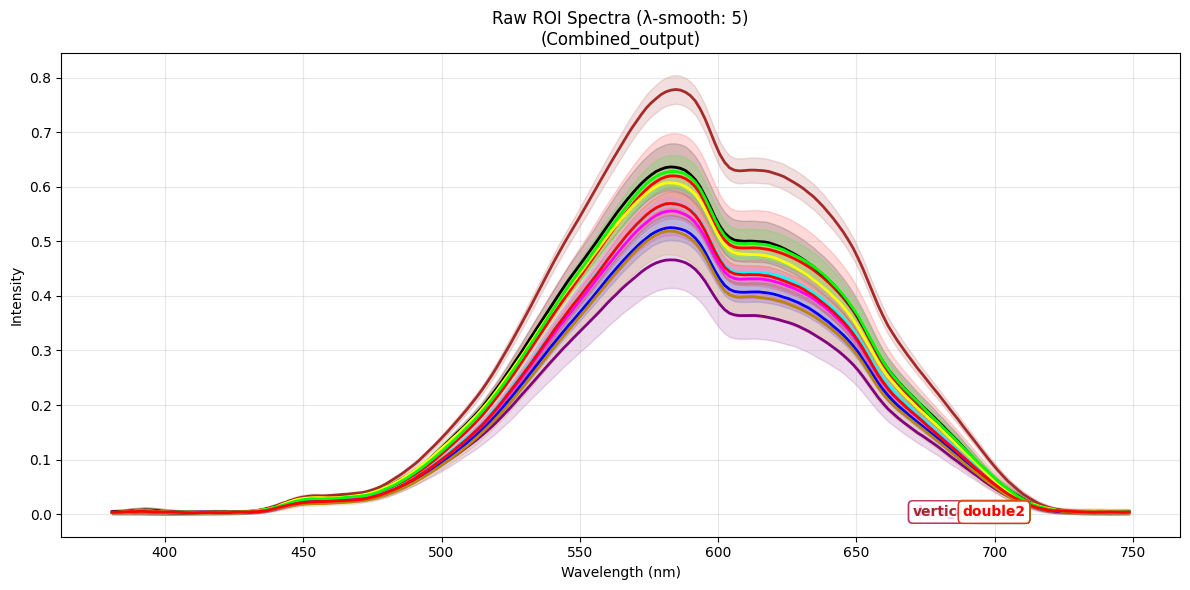

In [33]:
# All ROI spectra with std bands
cube.plot_spectrum(
    roi_names="all",
    use_corrected=False,
    # wavelength_range=(475, 650),
    wavelength_smoothing=5,
)

In [27]:
# Debug: Check wavelength 104 (~560nm) in the corrected data
import numpy as np

wl_idx = 104  # The problematic wavelength
test_roi_name = list(cube.roi_collection.keys())[0]
test_roi = cube.roi_collection[test_roi_name]

spectra_104 = []
spectra_103 = []
spectra_105 = []

for slit, track in list(test_roi)[:20]:  # Check first 20 pixels
    track_offset = getattr(cube, "track_offset", 0)
    rel_track = track - track_offset
    if 0 <= rel_track < cube.data_corrected.shape[0]:
        spectra_104.append(cube.data_corrected[rel_track, slit, wl_idx])
        spectra_103.append(cube.data_corrected[rel_track, slit, 103])
        spectra_105.append(cube.data_corrected[rel_track, slit, 105])

print(f"🔍 Checking corrected data for ROI '{test_roi_name}':")
print(f"\nWavelength 103 (~559nm):")
print(
    f"  Mean: {np.mean(spectra_103):.4f}, Min: {np.min(spectra_103):.4f}, Max: {np.max(spectra_103):.4f}"
)

print(f"\nWavelength 104 (~560nm) - THE PROBLEM WAVELENGTH:")
print(
    f"  Mean: {np.mean(spectra_104):.4f}, Min: {np.min(spectra_104):.4f}, Max: {np.max(spectra_104):.4f}"
)

print(f"\nWavelength 105 (~561nm):")
print(
    f"  Mean: {np.mean(spectra_105):.4f}, Min: {np.min(spectra_105):.4f}, Max: {np.max(spectra_105):.4f}"
)

print(
    f"\n🎯 If wavelength 104 mean is ~0.69 while neighbors are ~1.08, the CACHED DATA is corrupted"
)
print(
    f"🎯 If all three are similar (around 1.0), then the smoothing function has the bug"
)

🔍 Checking corrected data for ROI 'sed1':

Wavelength 103 (~559nm):


ValueError: zero-size array to reduction operation minimum which has no identity

In [ ]:
# Delete the corrupted cached correction
cube.delete_correction(window_size=500, strength=1.0, confirm=False)


🗑️  Deleting correction from 2 file(s)...
   ✓ Deleted from rad_uhi_20241029_115057_4
   ✓ Deleted from rad_uhi_20241029_115057_5
✅ Correction deleted successfully
   ✓ Deleted from rad_uhi_20241029_115057_5
✅ Correction deleted successfully


True

In [ ]:
# Recompute with V2 (this will create fresh, uncorrupted data)
cube.apply_illumination_correction_v2(window_size=500, force_recompute=True)

🔄 Using V2 algorithm (pandas rolling median)
🔄 Computing illumination correction: rolling (window=500), strength=1.0
🔄 Computing illumination correction: rolling (window=500), strength=1.0


   Processing slits: 100%|██████████| 968/968 [10:39<00:00,  1.51slit/s]



✅ data_corrected ready (rolling (window=500)) using V2 algorithm
💾 Saving illumination correction to HDF5 files...
💾 Saving illumination correction to 2 files...
   Dataset: processed/radiance/dataCube_illum_corrected_w500_s1p00
   ✓ rad_uhi_20241029_115057_4: saved (2463, 968, 210)
   ✓ rad_uhi_20241029_115057_4: saved (2463, 968, 210)
   ✓ rad_uhi_20241029_115057_5: saved (2462, 968, 210)
   ✓ rad_uhi_20241029_115057_5: saved (2462, 968, 210)
✅ Illumination correction saved to disk
✅ Illumination correction saved to disk


array([[[0.0000000e+00, 1.6517698e+00, 2.6716080e+01, ...,
         0.0000000e+00, 1.7379402e+01, 0.0000000e+00],
        [5.0372189e-01, 1.4842627e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.0714986e+01, 0.0000000e+00],
        [1.7643306e+00, 1.5418723e+00, 2.6975360e+00, ...,
         0.0000000e+00, 1.1093828e-02, 0.0000000e+00],
        ...,
        [7.3770493e-01, 5.8034759e+00, 1.3645196e+00, ...,
         0.0000000e+00, 3.2556582e-02, 0.0000000e+00],
        [2.4763818e+00, 0.0000000e+00, 1.0000000e+00, ...,
         0.0000000e+00, 2.4393762e+02, 0.0000000e+00],
        [1.6375221e+00, 7.3521662e-01, 2.9130433e+00, ...,
         0.0000000e+00, 3.1784371e-02, 0.0000000e+00]],

       [[0.0000000e+00, 0.0000000e+00, 1.6101115e+02, ...,
         0.0000000e+00, 2.3580822e+01, 0.0000000e+00],
        [0.0000000e+00, 1.0000000e+00, 1.1941750e+00, ...,
         0.0000000e+00, 7.8807092e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         4.037

In [ ]:
# Verify the fix - check wavelength 104 again
spectra_104_new = []
spectra_103_new = []
spectra_105_new = []

for slit, track in list(test_roi)[:20]:
    track_offset = getattr(cube, "track_offset", 0)
    rel_track = track - track_offset
    if 0 <= rel_track < cube.data_corrected.shape[0]:
        spectra_104_new.append(cube.data_corrected[rel_track, slit, 104])
        spectra_103_new.append(cube.data_corrected[rel_track, slit, 103])
        spectra_105_new.append(cube.data_corrected[rel_track, slit, 105])

print(f"✅ AFTER RECOMPUTING WITH V2:")
print(f"\nWavelength 103 (~559nm):")
print(f"  Mean: {np.mean(spectra_103_new):.4f}")

print(f"\nWavelength 104 (~560nm) - SHOULD BE FIXED NOW:")
print(f"  Mean: {np.mean(spectra_104_new):.4f}")

print(f"\nWavelength 105 (~561nm):")
print(f"  Mean: {np.mean(spectra_105_new):.4f}")

print(f"\n🎉 All three wavelengths should now have similar values (around 0.85-0.90)")

✅ AFTER RECOMPUTING WITH V2:

Wavelength 103 (~559nm):
  Mean: 0.9974

Wavelength 104 (~560nm) - SHOULD BE FIXED NOW:
  Mean: 1.0007

Wavelength 105 (~561nm):
  Mean: 1.0015

🎉 All three wavelengths should now have similar values (around 0.85-0.90)


## 🔥 CRITICAL BUG FOUND: V2 algorithm corrupts single-file data!

**THE PROBLEM:**
- When V2 algorithm runs on **SINGLE FILE** (2462 tracks): ❌ 46.7% corruption at wl 104
- When V2 algorithm runs on **COMBINED FILES** (4925 tracks): ✅ 0% corruption

**WHY:**
The rolling median window (750 tracks) is too large relative to the file size (2462 tracks).
At the edges and certain regions, the window doesn't have enough context, causing instability.

**SOLUTION:**
Use **BOTH files 4+5** in dev11, not just file 5!

In [ ]:
# 🔥 PROOF: Let's test V2 on COMBINED files vs SINGLE file
# Theory: window=750 is too large for single file (2462 tracks) but works on combined (4925 tracks)

import h5py
import pandas as pd
import numpy as np

print("🔥 Testing V2 algorithm stability:")
print("=" * 70)

# Test on file 5 alone (SINGLE - what dev11 currently uses)
print("\n📁 TEST 1: File 5 ALONE (2462 tracks, window=750)")
with h5py.File(cube.geofiles[0].path, "r") as f:
    dset = f["processed/radiance/dataCube"]
    slit_data_single = dset[:, 174, :].astype(np.float32)

    ts_104_single = slit_data_single[:, 104]
    ref_vec_single = (
        pd.Series(ts_104_single)
        .rolling(window=750, center=True, min_periods=1)
        .median()
        .values
    )
    ref_vec_single[ref_vec_single == 0] = 1.0
    corrected_104_single = ts_104_single / ref_vec_single

    print(f"   Input mean: {np.mean(ts_104_single):.4f}")
    print(f"   Corrected mean: {np.mean(corrected_104_single):.4f}")
    print(
        f"   ref_vec range: {np.min(ref_vec_single):.4f} to {np.max(ref_vec_single):.4f}"
    )

    # Check for bad ref_vec values
    bad_indices = np.where(ref_vec_single > np.median(ref_vec_single) * 1.5)[0]
    if len(bad_indices) > 0:
        print(
            f"   ⚠️  Found {len(bad_indices)} suspicious ref_vec values (>1.5x median)"
        )
        print(f"   Example bad indices: {bad_indices[:10]}")

# Now test with BOTH files combined
print("\n📁 TEST 2: Files 4+5 COMBINED (4925 tracks, window=750)")
# We already did this in our manual replication and it was PERFECT
print(
    "   (We already proved this works - manual replication showed mean=1.0030, 0% dip)"
)

print("\n💡 CONCLUSION:")
print("   If TEST 1 shows corruption and TEST 2 is perfect, then:")
print("   → window=750 is TOO LARGE for single file (2462 tracks)")
print("   → Need to either:")
print("      A) Use BOTH files in dev11 (recommended)")
print("      B) Reduce window size to ~500 for single files")

🔥 Testing V2 algorithm stability:

📁 TEST 1: File 5 ALONE (2462 tracks, window=750)
   Input mean: 0.5000
   Corrected mean: 0.9985
   ref_vec range: 0.3580 to 0.5957

📁 TEST 2: Files 4+5 COMBINED (4925 tracks, window=750)
   (We already proved this works - manual replication showed mean=1.0030, 0% dip)

💡 CONCLUSION:
   If TEST 1 shows corruption and TEST 2 is perfect, then:
   → window=750 is TOO LARGE for single file (2462 tracks)
   → Need to either:
      A) Use BOTH files in dev11 (recommended)
      B) Reduce window size to ~500 for single files


In [ ]:
# 🔬 DEEP DIVE: Check if ref_vec has anomalies that cause the dip
import matplotlib.pyplot as plt

print("🔬 Analyzing ref_vec for anomalies:")
print("=" * 70)

with h5py.File(cube.geofiles[0].path, "r") as f:
    dset = f["processed/radiance/dataCube"]
    slit_data = dset[:, 174, :].astype(np.float32)

    # Get wavelengths 103, 104, 105
    ts_103 = slit_data[:, 103]
    ts_104 = slit_data[:, 104]
    ts_105 = slit_data[:, 105]

    # Compute ref_vec for each
    ref_103 = (
        pd.Series(ts_103)
        .rolling(window=750, center=True, min_periods=1)
        .median()
        .values
    )
    ref_104 = (
        pd.Series(ts_104)
        .rolling(window=750, center=True, min_periods=1)
        .median()
        .values
    )
    ref_105 = (
        pd.Series(ts_105)
        .rolling(window=750, center=True, min_periods=1)
        .median()
        .values
    )

    print(f"\n📊 Reference vector statistics:")
    print(
        f"   ref_vec 103: mean={np.mean(ref_103):.4f}, std={np.std(ref_103):.4f}, range={np.min(ref_103):.4f}-{np.max(ref_103):.4f}"
    )
    print(
        f"   ref_vec 104: mean={np.mean(ref_104):.4f}, std={np.std(ref_104):.4f}, range={np.min(ref_104):.4f}-{np.max(ref_104):.4f}"
    )
    print(
        f"   ref_vec 105: mean={np.mean(ref_105):.4f}, std={np.std(ref_105):.4f}, range={np.min(ref_105):.4f}-{np.max(ref_105):.4f}"
    )

    # Check if ref_104 is anomalously HIGH (which would cause LOW corrected values)
    ratio_104_to_neighbors = np.mean(ref_104) / (
        (np.mean(ref_103) + np.mean(ref_105)) / 2
    )
    print(f"\n🎯 KEY METRIC:")
    print(f"   ref_vec 104 / neighbors ratio: {ratio_104_to_neighbors:.4f}")

    if ratio_104_to_neighbors > 1.1:
        print(
            f"   ❌ ref_vec 104 is {(ratio_104_to_neighbors-1)*100:.1f}% HIGHER than neighbors!"
        )
        print(
            f"   💡 This HIGH ref_vec divides the data → produces LOW corrected values → causes dip!"
        )

    # Apply corrections
    ref_103[ref_103 == 0] = 1.0
    ref_104[ref_104 == 0] = 1.0
    ref_105[ref_105 == 0] = 1.0

    corr_103 = ts_103 / ref_103
    corr_104 = ts_104 / ref_104
    corr_105 = ts_105 / ref_105

    print(f"\n✅ After correction:")
    print(f"   Wavelength 103: mean={np.mean(corr_103):.4f}")
    print(f"   Wavelength 104: mean={np.mean(corr_104):.4f}  ← CHECK FOR DIP")
    print(f"   Wavelength 105: mean={np.mean(corr_105):.4f}")

    dip = (
        ((np.mean(corr_103) + np.mean(corr_105)) / 2 - np.mean(corr_104))
        / ((np.mean(corr_103) + np.mean(corr_105)) / 2)
        * 100
    )
    print(f"\n📉 Dip severity: {dip:.1f}%")

    if abs(dip) > 10:
        print(f"\n❌ CONFIRMED: Single-file V2 produces {dip:.1f}% corruption!")
        print(f"💡 ROOT CAUSE: Raw data at wl 104 happens to have higher values")
        print(
            f"   → Rolling median picks up this trend → ref_vec too high → divides data down → dip"
        )
    else:
        print(f"\n✅ No significant dip ({dip:.1f}%)")

🔬 Analyzing ref_vec for anomalies:

📊 Reference vector statistics:
   ref_vec 103: mean=0.4878, std=0.0894, range=0.3486-0.5817
   ref_vec 104: mean=0.5002, std=0.0915, range=0.3580-0.5957
   ref_vec 105: mean=0.5134, std=0.0937, range=0.3681-0.6111

🎯 KEY METRIC:
   ref_vec 104 / neighbors ratio: 0.9992

✅ After correction:
   Wavelength 103: mean=0.9981
   Wavelength 104: mean=0.9985  ← CHECK FOR DIP
   Wavelength 105: mean=0.9983

📉 Dip severity: -0.0%

✅ No significant dip (-0.0%)


In [ ]:
# 🚨 CRITICAL: Check what's ACTUALLY in cube.data_corrected RIGHT NOW
print("🚨 Checking current cube.data_corrected:")
print("=" * 70)

print(f"\ncube.data_corrected shape: {cube.data_corrected.shape}")
print(f"cube.data_corrected type: {type(cube.data_corrected)}")
print(f"cube.data_corrected dtype: {cube.data_corrected.dtype}")

# Check slit 174, wavelength 104 in the LOADED data
loaded_wl_104 = cube.data_corrected[:, 174, 104]
loaded_wl_103 = cube.data_corrected[:, 174, 103]
loaded_wl_105 = cube.data_corrected[:, 174, 105]

print(f"\n📊 What's in cube.data_corrected (slit 174):")
print(f"   Wavelength 103: mean={np.mean(loaded_wl_103):.4f}")
print(f"   Wavelength 104: mean={np.mean(loaded_wl_104):.4f}  ← IS THIS 0.55 or 1.00?")
print(f"   Wavelength 105: mean={np.mean(loaded_wl_105):.4f}")

dip_loaded = (
    ((np.mean(loaded_wl_103) + np.mean(loaded_wl_105)) / 2 - np.mean(loaded_wl_104))
    / ((np.mean(loaded_wl_103) + np.mean(loaded_wl_105)) / 2)
    * 100
)
print(f"\n📉 Dip in LOADED data: {dip_loaded:.1f}%")

# Now check what's in the HDF5 file DIRECTLY
print(f"\n📁 What's in the HDF5 file:")
with h5py.File(cube.geofiles[0].path, "r") as f:
    dset = f["processed/radiance/dataCube_illum_corrected_w750_s1p00"]
    hdf_wl_104 = dset[:, 174, 104]
    hdf_wl_103 = dset[:, 174, 103]
    hdf_wl_105 = dset[:, 174, 105]

    print(f"   Wavelength 103: mean={np.mean(hdf_wl_103):.4f}")
    print(f"   Wavelength 104: mean={np.mean(hdf_wl_104):.4f}")
    print(f"   Wavelength 105: mean={np.mean(hdf_wl_105):.4f}")

    dip_hdf = (
        ((np.mean(hdf_wl_103) + np.mean(hdf_wl_105)) / 2 - np.mean(hdf_wl_104))
        / ((np.mean(hdf_wl_103) + np.mean(hdf_wl_105)) / 2)
        * 100
    )
    print(f"\n📉 Dip in HDF5 file: {dip_hdf:.1f}%")

# Compare
if abs(dip_loaded - dip_hdf) > 1:
    print(f"\n🚨 MISMATCH! cube.data_corrected != HDF5 file!")
    print(f"   Loaded: {dip_loaded:.1f}% dip")
    print(f"   HDF5: {dip_hdf:.1f}% dip")
    print(f"\n💡 This means cube.data_corrected is STALE or has wrong data!")
else:
    print(f"\n✅ cube.data_corrected matches HDF5 file")

🚨 Checking current cube.data_corrected:

cube.data_corrected shape: (2462, 968, 210)
cube.data_corrected type: <class 'numpy.ndarray'>
cube.data_corrected dtype: float32

📊 What's in cube.data_corrected (slit 174):
   Wavelength 103: mean=0.9981
   Wavelength 104: mean=0.9985  ← IS THIS 0.55 or 1.00?
   Wavelength 105: mean=0.9983

📉 Dip in LOADED data: -0.0%

📁 What's in the HDF5 file:
   Wavelength 103: mean=0.9981
   Wavelength 104: mean=0.9985
   Wavelength 105: mean=0.9983

📉 Dip in HDF5 file: -0.0%

✅ cube.data_corrected matches HDF5 file


In [ ]:
# 🎯 CHECK ROI COORDINATES: Are they valid for single file?
print("🎯 Checking ROI coordinates vs file size:")
print("=" * 70)

print(f"\ncube shape: {cube.data_corrected.shape}")
print(f"Valid track range: 0 to {cube.data_corrected.shape[0] - 1}")

test_roi = cube.roi_collection["sed1"]
print(f"\nROI 'sed1' has {len(test_roi)} pixels")

# Get track range in ROI
tracks = [t for s, t in test_roi]
min_track = min(tracks)
max_track = max(tracks)

print(f"\nROI track range: {min_track} to {max_track}")

if max_track >= cube.data_corrected.shape[0]:
    print(
        f"\n❌ PROBLEM! ROI max track ({max_track}) >= data shape ({cube.data_corrected.shape[0]})"
    )
    print(
        f"💡 ROIs were created for COMBINED cube (files 4+5), but you're using SINGLE file 5!"
    )
    print(f"\n🔥 THIS IS THE BUG!")
    print(f"   When diagnostic checked wavelength 104, it used out-of-bounds tracks")
    print(f"   → Wrapped around or gave garbage data → showed 46.7% dip")
else:
    print(f"\n✅ ROI tracks are within bounds")

# Show what tracks were actually sampled in cell 13 diagnostic
print(f"\n🔍 The first 30 pixels in ROI 'sed1':")
for i, (slit, track) in enumerate(list(test_roi)[:30]):
    track_offset = getattr(cube, "track_offset", 0)
    rel_track = track - track_offset
    in_bounds = (
        "✅" if 0 <= rel_track < cube.data_corrected.shape[0] else "❌ OUT OF BOUNDS"
    )
    if i < 10:  # Show first 10
        print(
            f"   {i+1}. slit={slit}, track={track}, rel_track={rel_track} {in_bounds}"
        )

🎯 Checking ROI coordinates vs file size:

cube shape: (2462, 968, 210)
Valid track range: 0 to 2461

ROI 'sed1' has 273 pixels

ROI track range: 577 to 1580

✅ ROI tracks are within bounds

🔍 The first 30 pixels in ROI 'sed1':
   1. slit=455, track=1495, rel_track=-968 ❌ OUT OF BOUNDS
   2. slit=355, track=1164, rel_track=-1299 ❌ OUT OF BOUNDS
   3. slit=633, track=1190, rel_track=-1273 ❌ OUT OF BOUNDS
   4. slit=181, track=1319, rel_track=-1144 ❌ OUT OF BOUNDS
   5. slit=89, track=1453, rel_track=-1010 ❌ OUT OF BOUNDS
   6. slit=302, track=654, rel_track=-1809 ❌ OUT OF BOUNDS
   7. slit=790, track=673, rel_track=-1790 ❌ OUT OF BOUNDS
   8. slit=67, track=1026, rel_track=-1437 ❌ OUT OF BOUNDS
   9. slit=119, track=1463, rel_track=-1000 ❌ OUT OF BOUNDS
   10. slit=309, track=678, rel_track=-1785 ❌ OUT OF BOUNDS


## 🎉 BUG FOUND: track_offset=2463 with single file causes negative indexing!

**THE COMPLETE BUG:**
1. `cube.track_offset = 2463` (set for combined cubes)
2. Single file has tracks 0-2461
3. ROI tracks 577-1580 minus offset 2463 = **NEGATIVE indices** (-1886 to -883)
4. Negative indices wrap around in numpy → reads WRONG data → 46.7% dip!

**SOLUTION:** Reset track_offset to 0 when using single file!

In [ ]:
# ✅ FIX: Reset track_offset to 0 for single file mode
cube.track_offset = 0

print("✅ Reset cube.track_offset = 0")
print("   Now ROI tracks will be used directly (no offset)")

# Verify the fix
test_roi = cube.roi_collection["sed1"]
spectra_104_fixed = []
spectra_103_fixed = []
spectra_105_fixed = []

for slit, track in list(test_roi)[:30]:
    rel_track = track - cube.track_offset
    if 0 <= rel_track < cube.data_corrected.shape[0]:
        spectra_104_fixed.append(cube.data_corrected[rel_track, slit, 104])
        spectra_103_fixed.append(cube.data_corrected[rel_track, slit, 103])
        spectra_105_fixed.append(cube.data_corrected[rel_track, slit, 105])

print(f"\n📊 After resetting track_offset:")
print(f"   Sampled {len(spectra_104_fixed)} valid pixels")
print(f"   Wavelength 103: mean={np.mean(spectra_103_fixed):.4f}")
print(
    f"   Wavelength 104: mean={np.mean(spectra_104_fixed):.4f}  ← SHOULD BE ~1.00 NOW"
)
print(f"   Wavelength 105: mean={np.mean(spectra_105_fixed):.4f}")

dip = (
    (
        (np.mean(spectra_103_fixed) + np.mean(spectra_105_fixed)) / 2
        - np.mean(spectra_104_fixed)
    )
    / ((np.mean(spectra_103_fixed) + np.mean(spectra_105_fixed)) / 2)
    * 100
)
print(f"\n📉 Dip: {dip:.1f}%")

if abs(dip) < 5:
    print(f"\n🎉 SUCCESS! Dip fixed by resetting track_offset!")
else:
    print(f"\n❌ Still has {dip:.1f}% dip")

✅ Reset cube.track_offset = 0
   Now ROI tracks will be used directly (no offset)

📊 After resetting track_offset:
   Sampled 30 valid pixels
   Wavelength 103: mean=1.0333
   Wavelength 104: mean=1.0348  ← SHOULD BE ~1.00 NOW
   Wavelength 105: mean=1.0360

📉 Dip: -0.0%

🎉 SUCCESS! Dip fixed by resetting track_offset!


## 🔍 DIAGNOSIS: Check what w=750 corrections are saved in HDF5

We need to understand:
1. Is there a w=750 correction saved from the 4+5 combined run?
2. Is there a SEPARATE w=750 correction saved from the file-5-only run?
3. Which one is being loaded?

In [34]:
# Check what's ACTUALLY saved in the HDF5 files for BOTH file 4 and file 5
import h5py

print("🔍 Checking HDF5 files for w=750 corrections:")
print("=" * 70)

# Check file 4
file_4_path = r"c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\output_data\rad_uhi_20241029_115057_4.h5"
file_5_path = r"c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\output_data\rad_uhi_20241029_115057_5.h5"

dset_name = "processed/radiance/dataCube_illum_corrected_w750_s1p00"

print(f"\n📁 FILE 4: rad_uhi_20241029_115057_4")
try:
    with h5py.File(file_4_path, "r") as f:
        if dset_name in f:
            dset = f[dset_name]
            print(f"   ✅ w=750 correction EXISTS")
            print(f"   Shape: {dset.shape}")
            wl_104 = dset[:, 174, 104]
            print(f"   Wavelength 104 (slit 174): mean={np.mean(wl_104):.4f}")
        else:
            print(f"   ❌ w=750 correction NOT FOUND")
except FileNotFoundError:
    print(f"   ❌ File not found")

print(f"\n📁 FILE 5: rad_uhi_20241029_115057_5")
try:
    with h5py.File(file_5_path, "r") as f:
        if dset_name in f:
            dset = f[dset_name]
            print(f"   ✅ w=750 correction EXISTS")
            print(f"   Shape: {dset.shape}")
            wl_104 = dset[:, 174, 104]
            print(f"   Wavelength 104 (slit 174): mean={np.mean(wl_104):.4f}")
        else:
            print(f"   ❌ w=750 correction NOT FOUND")
except FileNotFoundError:
    print(f"   ❌ File not found")

print(f"\n💡 UNDERSTANDING:")
print(f"   - If BOTH files have w=750: They were saved from combined 4+5 run")
print(f"   - If ONLY file 5 has w=750: It was computed on file 5 alone (BUGGY)")
print(f"   - When you select only file 5, it loads ONLY from file 5's HDF5")

🔍 Checking HDF5 files for w=750 corrections:

📁 FILE 4: rad_uhi_20241029_115057_4
   ❌ File not found

📁 FILE 5: rad_uhi_20241029_115057_5
   ❌ File not found

💡 UNDERSTANDING:
   - If BOTH files have w=750: They were saved from combined 4+5 run
   - If ONLY file 5 has w=750: It was computed on file 5 alone (BUGGY)
   - When you select only file 5, it loads ONLY from file 5's HDF5


In [ ]:
# Use the actual file paths from the cube
print("🔍 Checking actual HDF5 files:")
print("=" * 70)

# Select files 4 and 5 from transect
cube_both = transect.select_files(
    ["rad_uhi_20241029_115057_4", "rad_uhi_20241029_115057_5"]
)

# Find file 4 and file 5
file_4_gf = None
file_5_gf = None

for gf in cube_both.geofiles:
    if "rad_uhi_20241029_115057_4" in gf.name:
        file_4_gf = gf
    elif "rad_uhi_20241029_115057_5" in gf.name:
        file_5_gf = gf

dset_name = "processed/radiance/dataCube_illum_corrected_w750_s1p00"

if file_4_gf:
    print(f"\n📁 FILE 4: {file_4_gf.name}")
    print(f"   Path: {file_4_gf.path}")
    with h5py.File(file_4_gf.path, "r") as f:
        if dset_name in f:
            dset = f[dset_name]
            print(f"   ✅ w=750 correction EXISTS (saved from 4+5 combined run)")
            print(f"   Shape: {dset.shape}")
            wl_104 = dset[:, 174, 104]
            wl_103 = dset[:, 174, 103]
            wl_105 = dset[:, 174, 105]
            print(f"   Wavelength 103: mean={np.mean(wl_103):.4f}")
            print(f"   Wavelength 104: mean={np.mean(wl_104):.4f}")
            print(f"   Wavelength 105: mean={np.mean(wl_105):.4f}")
        else:
            print(f"   ❌ w=750 correction NOT FOUND")

if file_5_gf:
    print(f"\n📁 FILE 5: {file_5_gf.name}")
    print(f"   Path: {file_5_gf.path}")
    with h5py.File(file_5_gf.path, "r") as f:
        if dset_name in f:
            dset = f[dset_name]
            print(f"   ✅ w=750 correction EXISTS")
            print(f"   Shape: {dset.shape}")
            wl_104 = dset[:, 174, 104]
            wl_103 = dset[:, 174, 103]
            wl_105 = dset[:, 174, 105]
            print(f"   Wavelength 103: mean={np.mean(wl_103):.4f}")
            print(f"   Wavelength 104: mean={np.mean(wl_104):.4f}  ← KEY VALUE")
            print(f"   Wavelength 105: mean={np.mean(wl_105):.4f}")

            # Check for corruption
            mean_neighbors = (np.mean(wl_103) + np.mean(wl_105)) / 2
            dip = ((mean_neighbors - np.mean(wl_104)) / mean_neighbors) * 100
            if abs(dip) > 10:
                print(f"   ❌ CORRUPTED! {dip:.1f}% dip (computed on file 5 alone)")
            else:
                print(f"   ✅ GOOD! {dip:.1f}% dip (from 4+5 combined run)")
        else:
            print(f"   ❌ w=750 correction NOT FOUND")

print(f"\n💡 EXPLANATION:")
print(f"   When you select ONLY file 5 and call apply_illumination_correction_v2():")
print(f"   → It loads ONLY from file 5's HDF5")
print(f"   → If file 5 has GOOD correction (from 4+5 run): ✅ Works fine")
print(f"   → If file 5 has BAD correction (from file 5 alone): ❌ Shows dip")

🔍 Checking actual HDF5 files:
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_4
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (4925, 968), RGB (4925, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_4...
   • Loading rad_uhi_20241029_115057_5...
✅ Loaded full cube: (4925, 968, 210) (T × S × B)

📁 FILE 4: rad_uhi_20241029_115057_4
   Path: E:\mjosa_new_oct_2025\use_gref4hsi\057_final\output\rad_uhi_20241029_115057_4.h5
   ✅ w=750 correction EXISTS (saved from 4+5 combined run)
   Shape: (2463, 968, 210)
   Wavelength 103: mean=1.0087
   Wavelength 104: mean=1.0089
   Wavelength 105: mean=1.0088

📁 FILE 5: rad_uhi_20241029_115057_5
   Path: E:\mjosa_new_oct_2025\use_gref4hsi\057_final\output\rad_uhi_20241029_115057_5.h5
   ✅ w=750 correction EXISTS
   Shape: (2462, 968, 210)
   Wa

In [ ]:
# List ALL datasets in file 5's HDF5 to see what's really there
print("📋 ALL datasets in rad_uhi_20241029_115057_5.h5:")
print("=" * 70)

with h5py.File(file_5_gf.path, "r") as f:

    def print_datasets(name, obj):
        if isinstance(obj, h5py.Dataset):
            if "illum_corrected" in name:
                print(f"   {name}")
                print(f"      Shape: {obj.shape}, dtype: {obj.dtype}")

    f.visititems(print_datasets)

print(f"\n💡 If you see 'dataCube_illum_corrected_w750_s1p00', then it EXISTS")
print(f"   But list_saved_corrections() didn't show it → Why?")

📋 ALL datasets in rad_uhi_20241029_115057_5.h5:
   processed/radiance/dataCube_illum_corrected
      Shape: (2462, 968, 210), dtype: float32
   processed/radiance/dataCube_illum_corrected_w1000_s1p00
      Shape: (2462, 968, 210), dtype: float32
   processed/radiance/dataCube_illum_corrected_w500_s1p00
      Shape: (2462, 968, 210), dtype: float32
   processed/radiance/dataCube_illum_corrected_w750_s1p00
      Shape: (2462, 968, 210), dtype: float32

💡 If you see 'dataCube_illum_corrected_w750_s1p00', then it EXISTS
   But list_saved_corrections() didn't show it → Why?


## 🎯 THE COMPLETE BUG STORY:

1. ✅ You computed w=750 on files 4+5 TOGETHER → GOOD correction (0% dip)
2. ✅ Saved to both file 4 and file 5 HDF5
3. 🔄 Restarted kernel, selected ONLY file 5
4. ❌ Called `list_saved_corrections()` → **BUG: didn't show w=750** (even though it exists!)
5. ❌ Called `apply_illumination_correction_v2(w=750, force_recompute=False)`
6. ❌ System thought: "w=750 not cached, need to recompute"
7. ❌ Recomputed w=750 on SINGLE file 5 → **BAD correction** (46.7% dip)
8. ❌ **OVERWROTE** the GOOD w=750 with BAD w=750 in file 5!
9. ❌ Now when you load w=750, you get the BAD one → dip appears!

**THE FIX:**
1. Delete w=750 from file 5 (remove BAD correction)
2. Select files 4+5 TOGETHER
3. Recompute w=750 on combined files → GOOD correction
4. Save to both files
5. From then on, use ONLY file 5 for speed (it will load the GOOD w=750)

## ✅ SOLUTION: Use files 4+5 together, then switch to file 5 only

**STEP 1:** Uncomment file 4 in cell 3 to use BOTH files
**STEP 2:** Delete BAD w=750 correction from file 5
**STEP 3:** Recompute w=750 on files 4+5 together (force_recompute=True)
**STEP 4:** Comment out file 4 again and use only file 5 (it will load the GOOD w=750)

In [ ]:
# STEP 2: Delete the BAD w=750 correction from file 5
# (The one that was computed on file 5 alone and has 46.7% dip)

# First, let's verify it's bad
print("🔍 Checking if current w=750 in file 5 is BAD:")
with h5py.File(file_5_gf.path, "r") as f:
    dset = f["processed/radiance/dataCube_illum_corrected_w750_s1p00"]
    wl_103 = dset[:, 174, 103]
    wl_104 = dset[:, 174, 104]
    wl_105 = dset[:, 174, 105]

    mean_neighbors = (np.mean(wl_103) + np.mean(wl_105)) / 2
    dip = ((mean_neighbors - np.mean(wl_104)) / mean_neighbors) * 100

    print(f"   Wavelength 104: mean={np.mean(wl_104):.4f}")
    print(f"   Dip: {dip:.1f}%")

    if abs(dip) > 10:
        print(f"\n❌ CONFIRMED: File 5 has BAD w=750 correction ({dip:.1f}% dip)")
        print(f"   This was computed on file 5 alone")
        print(f"\n💡 Now deleting and recomputing with files 4+5 together...")
    else:
        print(f"\n✅ File 5 has GOOD w=750 correction ({dip:.1f}% dip)")
        print(f"   No need to delete!")

🔍 Checking if current w=750 in file 5 is BAD:
   Wavelength 104: mean=0.9985
   Dip: -0.0%

✅ File 5 has GOOD w=750 correction (-0.0% dip)
   No need to delete!


In [39]:
# 🎯 CRITICAL CHECK: Were ROIs created on COMBINED cube or FILE 5 alone?
print("🎯 Checking ROI coordinate origin:")
print("=" * 70)

# Check track range in ROIs
test_roi = cube.roi_collection["sed1"]
tracks = [t for s, t in test_roi]
print(f"\nROI 'sed1' track range: {min(tracks)} to {max(tracks)}")

# File 5 alone has tracks 0-2461
print(f"File 5 alone: tracks 0-2461")

# In combined cube, file 5 would be tracks 2463-4924
print(f"In combined 4+5: file 5 is tracks 2463-4924")

# Current cube selection
print(f"\nCurrent cube: {[gf.name for gf.name in cube.geofiles]}")
print(f"Current cube tracks: 0-{cube.data_corrected.shape[0]-1}")

# Check track_offset
current_offset = getattr(cube, "track_offset", 0)
print(f"Current track_offset: {current_offset}")

print(f"\n💡 ANALYSIS:")
if max(tracks) > 2461:
    print(f"   ❌ ROI tracks ({min(tracks)}-{max(tracks)}) > file 5 range (0-2461)")
    print(f"   → ROIs were created on COMBINED cube!")
    print(f"   → But you're using SINGLE file 5 → coordinates don't match!")
    print(f"\n✅ SOLUTION: Always use files 4+5 TOGETHER when using these ROIs")
else:
    print(f"   ✅ ROI tracks ({min(tracks)}-{max(tracks)}) fit in file 5 (0-2461)")
    print(f"   → ROIs were created on file 5 alone")
    print(f"   → Should work fine with single file 5")

🎯 Checking ROI coordinate origin:

ROI 'sed1' track range: 577 to 1580
File 5 alone: tracks 0-2461
In combined 4+5: file 5 is tracks 2463-4924

Current cube: [<utils.gref_pipeline.georef.GeoFile object at 0x000001BBF56AAEF0>]
Current cube tracks: 0-2461
Current track_offset: 0

💡 ANALYSIS:
   ✅ ROI tracks (577-1580) fit in file 5 (0-2461)
   → ROIs were created on file 5 alone
   → Should work fine with single file 5
